In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Load & Explore Data

In [ ]:
data = df = pd.read_csv('balanced_app_reviews.csv')
df = pd.DataFrame(data)

df = df.rename(columns={'clean_content': 'text', 'labelScore': 'label'})
df = df[['text', 'label']].dropna()

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (91656, 2)


,text,label
0,complicated application already vaccinated but...,Negative
1,error granting a certificate that should be th...,Negative
2,too often want to update,Negative
3,not_be downloaded,Negative
4,slow not_updated,Negative


Label distribution:
label
Positive    33196
Negative    32077
Neutral     26383
Name: count, dtype: int64


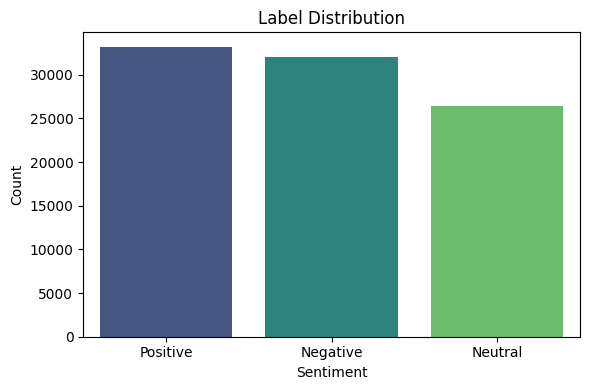

In [14]:

label_counts = df['label'].value_counts()
print('Label distribution:')
print(label_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Label Encoding

In [15]:
# Encode labels: Negative=0, Neutral=1, Positive=2
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
id2label  = {v: k for k, v in label_map.items()}

df['label_id'] = df['label'].map(label_map)
NUM_LABELS = len(label_map)

print('Label mapping:', label_map)
df[['label', 'label_id']].value_counts().sort_index()

Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


label     label_id
Negative  0           32077
Neutral   1           26383
Positive  2           33196
Name: count, dtype: int64

## Train / Validation / Test Split

In [16]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label_id']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label_id']
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 64159 | Val: 13748 | Test: 13749


## Tokenizer & Dataset Class

In [17]:
MODEL_NAME  = 'bert-base-uncased'
MAX_LEN     = 128
BATCH_SIZE  = 16

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')

Tokenizer loaded.


In [19]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = SentimentDataset(train_df['text'], train_df['label_id'], tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(val_df['text'],   val_df['label_id'],   tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(test_df['text'],  test_df['label_id'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 4010 | Val batches: 860 | Test batches: 860


## Load Pre-trained BERT Model

In [20]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = NUM_LABELS,
    id2label   = id2label,
    label2id   = label_map
)
model = model.to(device)
print(f'Model loaded → {MODEL_NAME}  |  Labels: {NUM_LABELS}')

Loading weights: 100%|██████████| 199/199 [00:02<00:00, 78.51it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

Model loaded → bert-base-uncased  |  Labels: 3


## Optimizer & Scheduler

In [21]:
EPOCHS        = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Total steps: 16040 | Warmup steps: 1604


## Training & Validation Loop

In [22]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(outputs.logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [24]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    print(f'\n── Epoch {epoch}/{EPOCHS} ──────────────────────────')
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, device)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'  Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}')
    print(f'  Val   Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_bert_sentiment.pt')
        print(f'   Best model saved (val_acc={best_val_acc:.4f})')

print('\nTraining complete.')


── Epoch 1/4 ──────────────────────────
  Train Loss: 0.8313  Acc: 0.6177
  Val   Loss: 0.7806  Acc: 0.6496
   Best model saved (val_acc=0.6496)

── Epoch 2/4 ──────────────────────────
  Train Loss: 0.7366  Acc: 0.6744
  Val   Loss: 0.7885  Acc: 0.6579
   Best model saved (val_acc=0.6579)

── Epoch 3/4 ──────────────────────────
  Train Loss: 0.6599  Acc: 0.7167
  Val   Loss: 0.8131  Acc: 0.6472

── Epoch 4/4 ──────────────────────────
  Train Loss: 0.5767  Acc: 0.7618
  Val   Loss: 0.9028  Acc: 0.6393

Training complete.


## Training Curves

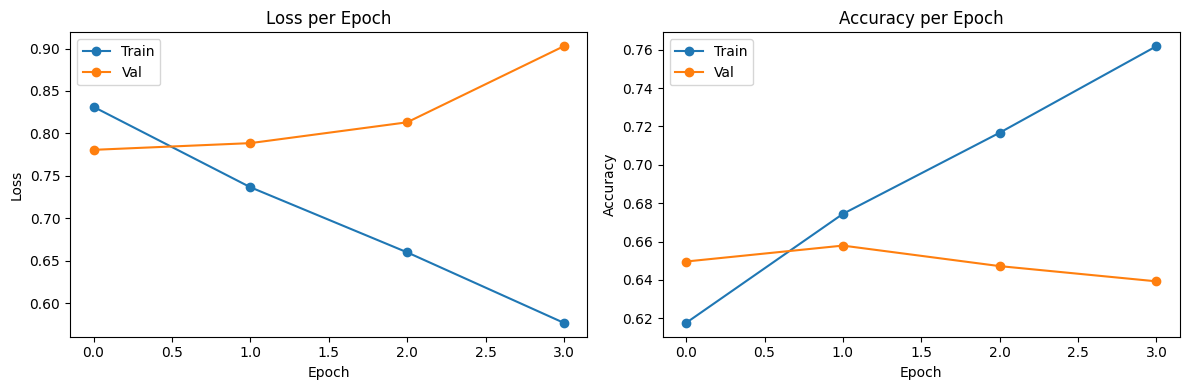

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'],   label='Val',   marker='o')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluate on Test Set

In [26]:
# Load best weights
model.load_state_dict(torch.load('best_bert_sentiment.pt', map_location=device))

_, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, device)
print(f'Test Accuracy: {test_acc:.4f}\n')
print(classification_report(
    test_labels, test_preds,
    target_names=list(label_map.keys())
))

Test Accuracy: 0.6591

              precision    recall  f1-score   support

    Negative       0.64      0.81      0.72      4812
     Neutral       0.50      0.29      0.36      3957
    Positive       0.74      0.81      0.77      4980

    accuracy                           0.66     13749
   macro avg       0.63      0.64      0.62     13749
weighted avg       0.64      0.66      0.64     13749



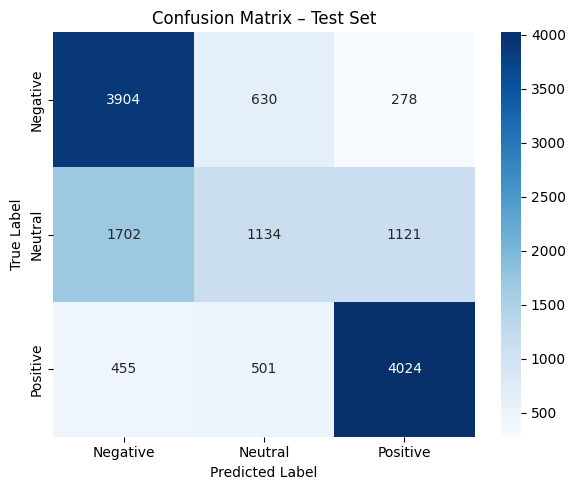

In [27]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=list(label_map.keys()),
    yticklabels=list(label_map.keys())
)
plt.title('Confusion Matrix – Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Testing

In [ ]:
def predict_sentiment(text, model, tokenizer, device, max_len=128):
    model.eval()
    encoding = tokenizer(
        text,
        max_length     = max_len,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids      = encoding['input_ids'].to(device),
            attention_mask = encoding['attention_mask'].to(device)
        )
    probs      = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
    pred_id    = probs.argmax()
    pred_label = id2label[pred_id]
    confidence = probs[pred_id]
    return pred_label, confidence, dict(zip(label_map.keys(), probs.round(4).tolist()))


samples = [
    'This application is very helpful and easy to use',
    'The app keeps crashing and the data is wrong',
    'The app is okay, nothing special'
]

for s in samples:
    label, conf, probs = predict_sentiment(s, model, tokenizer, device)
    print(f'Text : {s}')
    print(f'  → Prediction : {label}  (confidence: {conf:.2%})')
    print(f'  → Probabilities : {probs}\n')

Text : This application is very helpful and easy to use
  → Prediction : Positive  (confidence: 90.38%)
  → Probabilities : {'Negative': 0.0203000009059906, 'Neutral': 0.07590000331401825, 'Positive': 0.9038000106811523}

Text : The app keeps crashing and the data is wrong
  → Prediction : Negative  (confidence: 94.31%)
  → Probabilities : {'Negative': 0.9430999755859375, 'Neutral': 0.05090000107884407, 'Positive': 0.006000000052154064}

Text : The app is okay, nothing special
  → Prediction : Neutral  (confidence: 51.40%)
  → Probabilities : {'Negative': 0.20190000534057617, 'Neutral': 0.5139999985694885, 'Positive': 0.2840999960899353}



## 13. Save Model & Tokenizer

In [29]:

SAVE_DIR = '../streamlit/models/bert_sentiment_model'
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Model and tokenizer saved to: {SAVE_DIR}')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.92it/s]

Model and tokenizer saved to: ../streamlit/models/bert_sentiment_model
